# Explore here

# PREDICCION DE IMAGENES


In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image

Mostrando perros aleatorios...


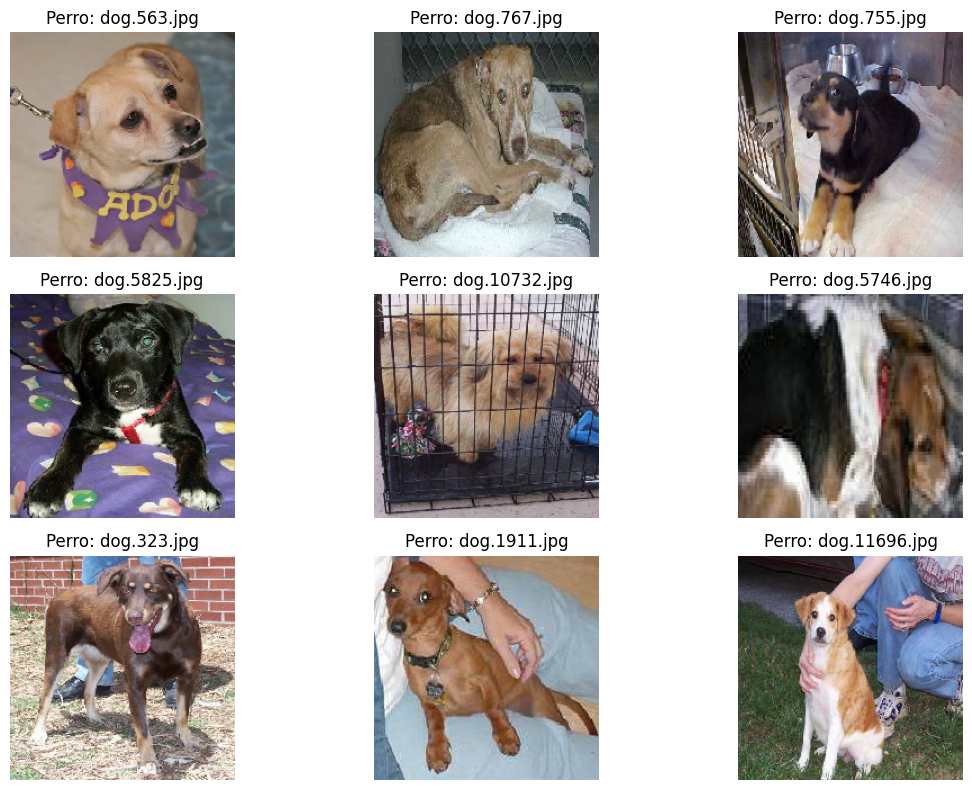

Mostrando gatos aleatorios...


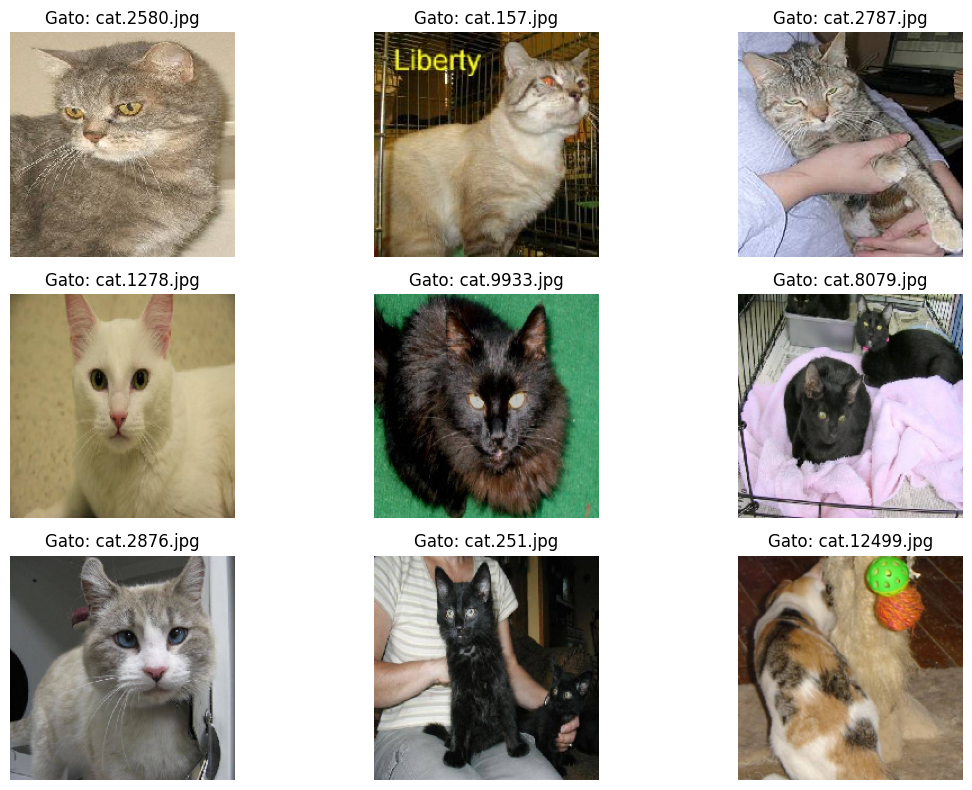

In [31]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Configurar rutas
train_dir = "../data/raw/train"
all_files = os.listdir(train_dir)

# 2. Filtrar archivos por nombre
dog_files = [f for f in all_files if f.startswith('dog')]
cat_files = [f for f in all_files if f.startswith('cat')]

# 3. Seleccionar 9 aleatorios de cada uno
random_dogs = random.sample(dog_files, 9)
random_cats = random.sample(cat_files, 9)

def plot_images(file_list, title_prefix):
    plt.figure(figsize=(12, 8))
    for i, file_name in enumerate(file_list):
        img_path = os.path.join(train_dir, file_name)
        
        # Cargamos la imagen (ajusta target_size según tu modelo, ej: 150x150)
        img = image.load_img(img_path, target_size=(200, 200))
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{title_prefix}: {file_name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 4. Mostrar los resultados
print("Mostrando perros aleatorios...")
plot_images(random_dogs, "Perro")

print("Mostrando gatos aleatorios...")
plot_images(random_cats, "Gato")

In [32]:
import pandas as pd

# Listamos todos los archivos
filenames = os.listdir("../data/raw/train")
categories = []

for name in filenames:
    category = name.split('.')[0] # Esto toma 'dog' o 'cat' antes del primer punto
    categories.append(category)

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

# Verificamos los primeros datos
print(df.head())

       filename category
0     cat.0.jpg      cat
1     cat.1.jpg      cat
2    cat.10.jpg      cat
3   cat.100.jpg      cat
4  cat.1000.jpg      cat


In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definimos el generador (aquí puedes agregar Data Augmentation si quieres)
datagen = ImageDataGenerator(rescale=1/255.0, validation_split=0.2)

# Datos de entrenamiento (trdata)
trdata = datagen.flow_from_dataframe(
    df, 
    directory="../data/raw/train", 
    x_col='filename',
    y_col='category',
    target_size=(128, 128),
    class_mode='binary',
    batch_size=32,
    subset='training' # Usa el 80% para entrenar
)

# Datos de validación/prueba (tsdata)
tsdata = datagen.flow_from_dataframe(
    df, 
    directory="../data/raw/train", 
    x_col='filename',
    y_col='category',
    target_size=(128, 128),
    class_mode='binary',
    batch_size=32,
    subset='validation' # Usa el 20% restante para prueba
)

Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [34]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, MaxPool2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import set_random_seed

In [35]:
model = Sequential()
model.add(Conv2D(input_shape = (128,128,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 512, activation = "relu")) # Bajé de 4096 a 512 para que sea más rápido
model.add(Dropout(0.5)) 
model.add(Dense(1, activation='sigmoid'))

c:\Users\ddelg\OneDrive\Documents\4GEEKS\SERIES DE TIEMPO\NN_DOG_vs_CATS_DANIEL_DELGADO\venv_ds\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Compilar el modelo con Adam 
from keras.optimizers import Adam

# Compilar el modelo antes del entrenamiento
model.compile(
    loss = 'binary_crossentropy', # CAMBIO AQUÍ
    optimizer = Adam(learning_rate = 0.0001), # Un lr más bajo ayuda a no "saltarse" el mínimo
    metrics = ["accuracy"]
)

In [37]:
# Entrenar el modelo
# Usa el nombre exacto que le diste a tu generador
history = model.fit(
    trdata, 
    epochs=1, 
    validation_data=tsdata
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 811s 1s/step - accuracy: 0.6337 - loss: 0.6368 - val_accuracy: 0.3178 - val_loss: 0.9368


In [38]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("../models/vgg16_1.h5", monitor = "val_accuracy", verbose = 1, save_best_only = True, save_weights_only = False, mode = "auto")
early = EarlyStopping(monitor = "val_accuracy", patience = 3, verbose = 1, mode = "auto")
hist = model.fit(trdata, steps_per_epoch = 100, validation_data = tsdata, validation_steps = 10, epochs = 3, callbacks = [checkpoint, early])

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6625 - loss: 0.5933
Epoch 1: val_accuracy improved from None to 0.41563, saving model to ../models/vgg16_1.h5



Epoch 1: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6675 - loss: 0.5963 - val_accuracy: 0.4156 - val_loss: 0.7556
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6728 - loss: 0.5981
Epoch 2: val_accuracy did not improve from 0.41563
100/100 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6825 - loss: 0.5809 - val_accuracy: 0.4156 - val_loss: 0.8221
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6918 - loss: 0.5594
Epoch 3: val_accuracy improved from 0.41563 to 0.56563, saving model to ../models/vgg16_1.h5



Epoch 3: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6991 - loss: 0.5624 - val_accuracy: 0.5656 - val_loss: 0.7021


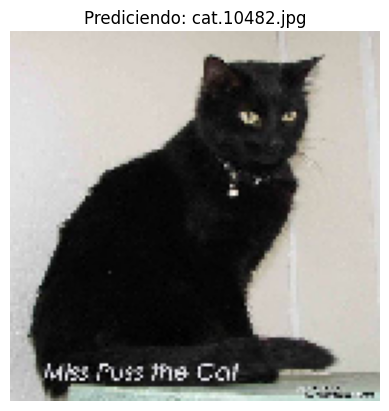

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Resultado para cat.10482.jpg:
Predicción: cat (valor: 2.1840332939879328e-16)


In [40]:
from keras.preprocessing import image
from keras.models import load_model

train_dir = "../data/raw/train" 

# 2. Obtener una lista de todos los archivos en la carpeta
files = [f for f in os.listdir(train_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# 3. Elegir un archivo al azar
random_file = random.choice(files)
file_path = os.path.join(train_dir, random_file)

# 4. Cargar y preprocesar la imagen elegida
img = image.load_img(file_path, target_size=(128, 128))
img_array = np.asarray(img)
plt.imshow(img)
plt.title(f"Prediciendo: {random_file}")
plt.axis('off')
plt.show()

# Preparar la imagen para el modelo
img_array = np.expand_dims(img_array, axis=0)

# 5. Cargar el modelo y predecir
# Nota: asegúrate de tener la ruta correcta a tu modelo guardado
saved_model = load_model("../models/vgg16_1.h5")
output = saved_model.predict(img_array)

# 6. Mostrar resultado
print(f"Resultado para {random_file}:")

# El modelo devuelve una probabilidad entre 0 y 1. 
# Si el valor es < 0.5, suele ser la clase 0 (cat). Si es >= 0.5, la clase 1 (dog).
# AJUSTA ESTO SEGÚN TU MODELO (si Gato es 0 o 1)
valor_predicho = output[0][0]

if valor_predicho < 0.5:
    print(f"Predicción: cat (valor: {valor_predicho})")
else:
    print(f"Predicción: dog (valor: {valor_predicho})")